In [ ]:
## loading the data after the data undergoes EDA
import pandas as pd

df = pd.read_csv("ai_ml_nlp_dataset.csv")

print(df.shape)
print(df.info())

(144053, 6)
<class 'pandas.DataFrame'>
RangeIndex: 144053 entries, 0 to 144052
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               144053 non-null  object
 1   abstract         144053 non-null  str   
 2   categories       144053 non-null  str   
 3   year             144053 non-null  int64 
 4   period           144053 non-null  str   
 5   abstract_length  144053 non-null  int64 
dtypes: int64(2), object(1), str(3)
memory usage: 6.6+ MB
None


C:\Users\pavit\AppData\Local\Temp\ipykernel_23292\103487933.py:4: DtypeWarning: Columns (0: id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ai_ml_nlp_dataset.csv")


Text Preprocessing

In [2]:
## checking the abstract to know wat are the content it conatin 
#print(df['abstract'].iloc[14])
#print(df['abstract'].iloc[0])
print(df['abstract'].iloc[100])

  This research hypothesized that a practical approach in the form of a
solution framework known as Natural Language Understanding and Reasoning for
Intelligence (NaLURI), which combines full-discourse natural language
understanding, powerful representation formalism capable of exploiting
ontological information and reasoning approach with advanced features, will
solve the following problems without compromising practicality factors: 1)
restriction on the nature of question and response, and 2) limitation to scale
across domains and to real-life natural language text.



In [3]:
## we will lower case all the words in the abstract 
df['cleaned'] = df['abstract'].str.lower()
print(df['cleaned'].iloc[100])

  this research hypothesized that a practical approach in the form of a
solution framework known as natural language understanding and reasoning for
intelligence (naluri), which combines full-discourse natural language
understanding, powerful representation formalism capable of exploiting
ontological information and reasoning approach with advanced features, will
solve the following problems without compromising practicality factors: 1)
restriction on the nature of question and response, and 2) limitation to scale
across domains and to real-life natural language text.



In [4]:
## remove the special characters 
import re

def remove_special(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text

df['cleaned'] = df['cleaned'].apply(remove_special)

print(df['cleaned'].iloc[100])

  this research hypothesized that a practical approach in the form of a
solution framework known as natural language understanding and reasoning for
intelligence  naluri   which combines full discourse natural language
understanding  powerful representation formalism capable of exploiting
ontological information and reasoning approach with advanced features  will
solve the following problems without compromising practicality factors    
restriction on the nature of question and response  and    limitation to scale
across domains and to real life natural language text 



In [7]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Error loading stopwords: <urlopen error [WinError 10054]
[nltk_data]     An existing connection was forcibly closed by the
[nltk_data]     remote host>
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pavit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_preprocessing_pipeline(text):
    # Step 1: Tokenization
    words = text.split()
    
    # Step 2: Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Step 3: Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # Step 4: Join back to string
    return " ".join(words)

In [12]:
df['clean_text'] = df['cleaned'].apply(text_preprocessing_pipeline)

In [19]:
#print(df)
df.isnull().sum()

id                 0
abstract           0
categories         0
year               0
period             0
abstract_length    0
cleaned            0
clean_text         0
dtype: int64

Text representation 

In [21]:
## TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
abstract = df['clean_text']
X = tfidf.fit_transform(abstract)
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10053899 stored elements and shape (144053, 5000)>

In [22]:
##analysis 
##Top keywords

import numpy as np

feature_names = tfidf.get_feature_names_out()

sums = np.array(X.sum(axis=0)).flatten()

top_indices = sums.argsort()[-550:]

top_words = [feature_names[i] for i in top_indices]

print(len(top_words))
top_words

550


['towards',
 'github',
 'building',
 'log',
 'choice',
 'competitive',
 'adaptation',
 'update',
 'speed',
 'product',
 'role',
 'enables',
 'yet',
 'bert',
 'importance',
 'exploration',
 'hand',
 'fast',
 'independent',
 'promising',
 'observed',
 'practice',
 'sentiment',
 'estimator',
 'operation',
 'binary',
 'speaker',
 'noisy',
 'alternative',
 'critical',
 'tuning',
 'item',
 'shot',
 'presented',
 'correlation',
 'learns',
 'spatial',
 'review',
 'build',
 'classical',
 'idea',
 'structured',
 'nlp',
 'short',
 'hierarchical',
 'impact',
 'attribute',
 'al',
 'conditional',
 'variant',
 'driven',
 'article',
 'descent',
 'recommendation',
 'region',
 'encoder',
 'dialogue',
 'benefit',
 'especially',
 'vision',
 'reduction',
 'therefore',
 'discus',
 'quantum',
 'module',
 'flow',
 'success',
 'additional',
 'difficult',
 'leverage',
 'approximate',
 'combine',
 'annotation',
 'stage',
 'medical',
 'widely',
 'http',
 'wide',
 'less',
 'aspect',
 'patient',
 'automatically',
 

In [23]:
## by time period
for period in df['period'].unique():
    subset = df[df['period'] == period]
    
    X_p = tfidf.fit_transform(subset['clean_text'])
    features = tfidf.get_feature_names_out()
    
    sums = np.array(X_p.sum(axis=0)).flatten()
    top_idx = sums.argsort()[-10:]
    
    words = [features[i] for i in top_idx]
    
    print(f"\n{period}:")
    print(words)


2007_2014:
['approach', 'based', 'system', 'network', 'learning', 'data', 'method', 'problem', 'model', 'algorithm']

2015_2021:
['problem', 'approach', 'based', 'task', 'algorithm', 'method', 'network', 'data', 'learning', 'model']

1999_2006:
['data', 'method', 'paper', 'based', 'language', 'logic', 'problem', 'system', 'algorithm', 'model']

1991_1998:
['approach', 'method', 'paper', 'algorithm', 'based', 'grammar', 'word', 'system', 'language', 'model']


In [24]:
## by category 

for cat in df['categories'].unique():
    subset = df[df['categories'] == cat]
    
    X_c = tfidf.fit_transform(subset['clean_text'])
    features = tfidf.get_feature_names_out()
    
    sums = np.array(X_c.sum(axis=0)).flatten()
    top_idx = sums.argsort()[-100:]
    
    words = [features[i] for i in top_idx]
    
    print(f"\n{cat}:")
    print(words)


cs.AI:
['concept', 'given', 'value', 'architecture', 'class', 'strategy', 'optimization', 'prediction', 'art', 'existing', 'intelligence', 'design', 'high', 'provide', 'many', 'inference', 'world', 'case', 'order', 'experiment', 'novel', 'analysis', 'large', 'theory', 'planning', 'however', 'structure', 'reasoning', 'research', 'rule', 'multi', 'number', 'first', 'space', 'well', 'language', 'level', 'action', 'constraint', 'study', 'robot', 'solution', 'machine', 'environment', 'training', 'policy', 'technique', 'real', 'application', 'search', 'logic', 'use', 'function', 'object', 'representation', 'deep', 'process', 'game', 'one', 'user', 'neural', 'work', 'graph', 'also', 'propose', 'two', 'feature', 'different', 'used', 'domain', 'present', 'decision', 'framework', 'new', 'ai', 'performance', 'proposed', 'state', 'information', 'set', 'time', 'image', 'show', 'using', 'knowledge', 'result', 'human', 'paper', 'task', 'agent', 'approach', 'based', 'method', 'network', 'data', 'algo

In [25]:
# N- grams 
# using the combination of bi-grams and tri-grams

tfidf_ngram = TfidfVectorizer(ngram_range=(2,3), max_features=5000)

X_ngram = tfidf_ngram.fit_transform(df['clean_text'])
print(X_ngram)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2620158 stored elements and shape (144053, 5000)>
  Coords	Values
  (0, 4178)	0.5128998471314297
  (0, 3485)	0.5268240228634216
  (0, 2934)	0.17478660084667383
  (0, 3461)	0.48785890564494516
  (0, 457)	0.43684497032006564
  (1, 4178)	0.7470763685923141
  (1, 729)	0.3111136436495163
  (1, 4772)	0.37013187584187857
  (1, 4167)	0.27972689659063293
  (1, 3185)	0.3603338147268282
  (2, 3191)	0.8797831073689671
  (2, 3207)	0.47537530855967347
  (3, 4257)	0.313942263709825
  (3, 3649)	0.576673537171977
  (3, 4629)	0.2714250184153315
  (3, 2007)	0.32185024230700837
  (3, 3458)	0.2525397738955855
  (3, 2283)	0.21813240649618695
  (3, 1946)	0.28223621201588833
  (3, 3304)	0.30999597104178045
  (3, 1616)	0.32328919234827985
  (4, 3965)	0.34666562834484677
  (4, 4539)	0.17333281417242338
  (4, 4086)	0.154789986582744
  (4, 3005)	0.15588522329696897
  :	:
  (144049, 2306)	0.26467275883898833
  (144049, 4738)	0.1412560663937792
  (144049

In [26]:
## embedding 
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

X_embed = model.encode(df['clean_text'], show_progress_bar=True)

c:\Users\pavit\OneDrive\Desktop\course work - AITA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2331.16it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4502/4502 [36:24<00:00,  2.06it/s]  


In [27]:
## compare similarity across periods
##Elements in the same period (row) show trends rather than direct similarity

import numpy as np

period_groups = df.groupby('period')

period_vectors = {}

for period, group in period_groups:
    period_vectors[period] = np.mean(X_embed[group.index], axis=0)

In [28]:
## similarity between periods 
##Elements in different periods but the same group (column) exhibit high similarity in chemical behavior.
## How similar are research papers from different time period
from sklearn.metrics.pairwise import cosine_similarity

for p1 in period_vectors:
    for p2 in period_vectors:
        sim = cosine_similarity(
            [period_vectors[p1]],
            [period_vectors[p2]]
        )[0][0]
        
        print(f"{p1} vs {p2}: {sim:.3f}")

1991_1998 vs 1991_1998: 1.000
1991_1998 vs 1999_2006: 0.911
1991_1998 vs 2007_2014: 0.788
1991_1998 vs 2015_2021: 0.726
1999_2006 vs 1991_1998: 0.911
1999_2006 vs 1999_2006: 1.000
1999_2006 vs 2007_2014: 0.946
1999_2006 vs 2015_2021: 0.832
2007_2014 vs 1991_1998: 0.788
2007_2014 vs 1999_2006: 0.946
2007_2014 vs 2007_2014: 1.000
2007_2014 vs 2015_2021: 0.901
2015_2021 vs 1991_1998: 0.726
2015_2021 vs 1999_2006: 0.832
2015_2021 vs 2007_2014: 0.901
2015_2021 vs 2015_2021: 1.000


In [29]:
## Classification - Logistic Regression

from sklearn.model_selection import train_test_split

X = tfidf.fit_transform(df['clean_text'])
y = df['period']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
##Logistic Regression - as this is used for the prediction of probabilities for binary outcomes.

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9093401825691576


In [31]:
##PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())
X_pca

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

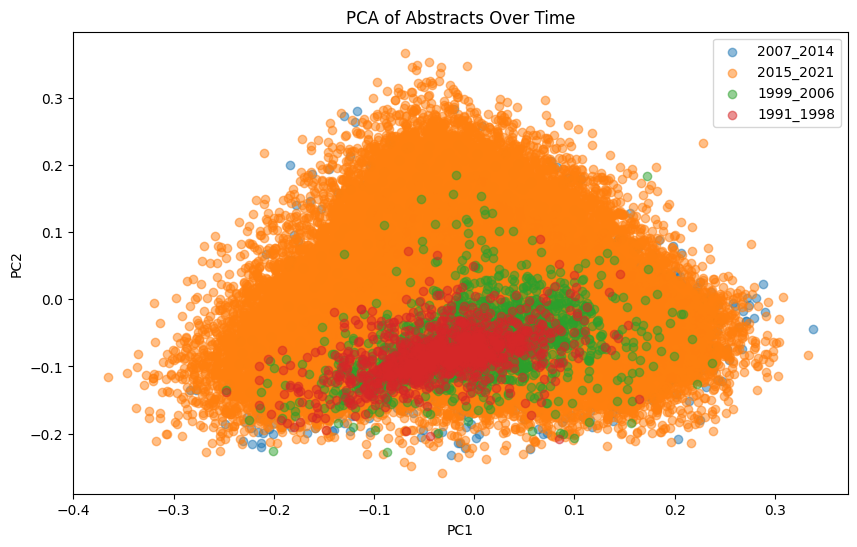

In [32]:
## High-dimensional text data --> Reduced to 2 dimensions using PCA 

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for period in df['period'].unique():
    subset = df[df['period'] == period]
    
    plt.scatter(
        subset['pca1'],
        subset['pca2'],
        label=period,
        alpha=0.5
    )

plt.legend()
plt.title("PCA of Abstracts Over Time")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

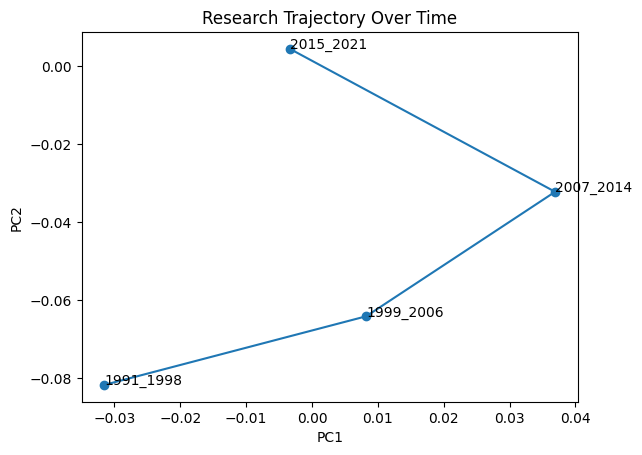

In [33]:
## average position of all abstracts in a time period 
plt.figure()
means = df.groupby('period')[['pca1', 'pca2']].mean()

plt.plot(means['pca1'], means['pca2'], marker='o')


for period in means.index:
    plt.text(
        means.loc[period, 'pca1'],
        means.loc[period, 'pca2'],
        period
    )

plt.title("Research Trajectory Over Time")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()